In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tapas_gmm_modified.policy.models.tpgmm import (
    ReconstructionStrategy, 
    FittingStage,
    InitStrategy,

)
from tapas_gmm_modified.dataset.demos import Demos
from tapas_gmm_modified.viz.gmm import plot_hmm_transition_matrix

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent.parent))

np.set_printoptions(precision=2)

plt.style.use('default')

from matplotlib import rc
rc('animation', html='jshtml')

2026-07-23 13:26:00.449 | INFO     |  Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
from heca.agents.experts.tapas import TapasAgent
from conf.agents.tapas import close_drawer as agent_cfg
agent = TapasAgent.get(agent_cfg, auto_load=True)
print(agent_cfg.policy.model.frame_selection.gt_frames)
selections = [0, 1, 3, 4, 5]

2026-07-23 13:26:02.441 | INFO     | heca.misc.logger:info:37 - Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


2026-07-23 13:26:03.671 | INFO     | heca.misc.logger:info:37 - Loading <class 'heca.agents.experts.tapas.TapasAgent'> from /home/jangruhnert/Documents/GitHub/heca/data/agents/tapas/close_drawer
2026-07-23 13:26:03.671 | WARNING  | heca.misc.logger:warning:33 - No tapas policy found at given path: /home/jangruhnert/Documents/GitHub/heca/data/agents/tapas/close_drawer/policy_gt.pt
[[0, 4], [4, 2], [4, 7]]


In [3]:
observations = agent.load_demos(selections)

demos = Demos(
    observations,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True,
)  # type: ignore
print("n_trajs", demos.n_trajs)
print("n_frames", demos.n_frames)
demos.frame_names


n_trajs 5
n_frames 8


('ee_init',
 'block_0',
 'button_0',
 'button_1',
 'drawer_handle',
 'window_handle',
 'block_0_target',
 'ee_target')

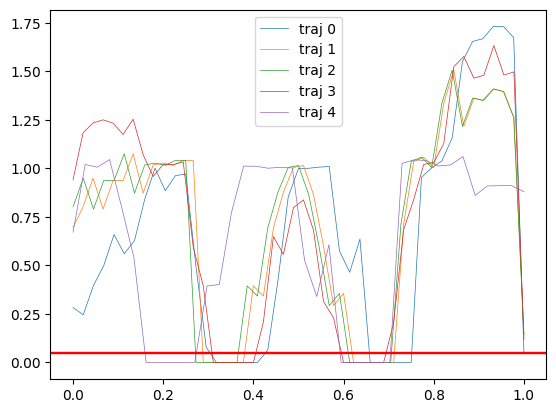

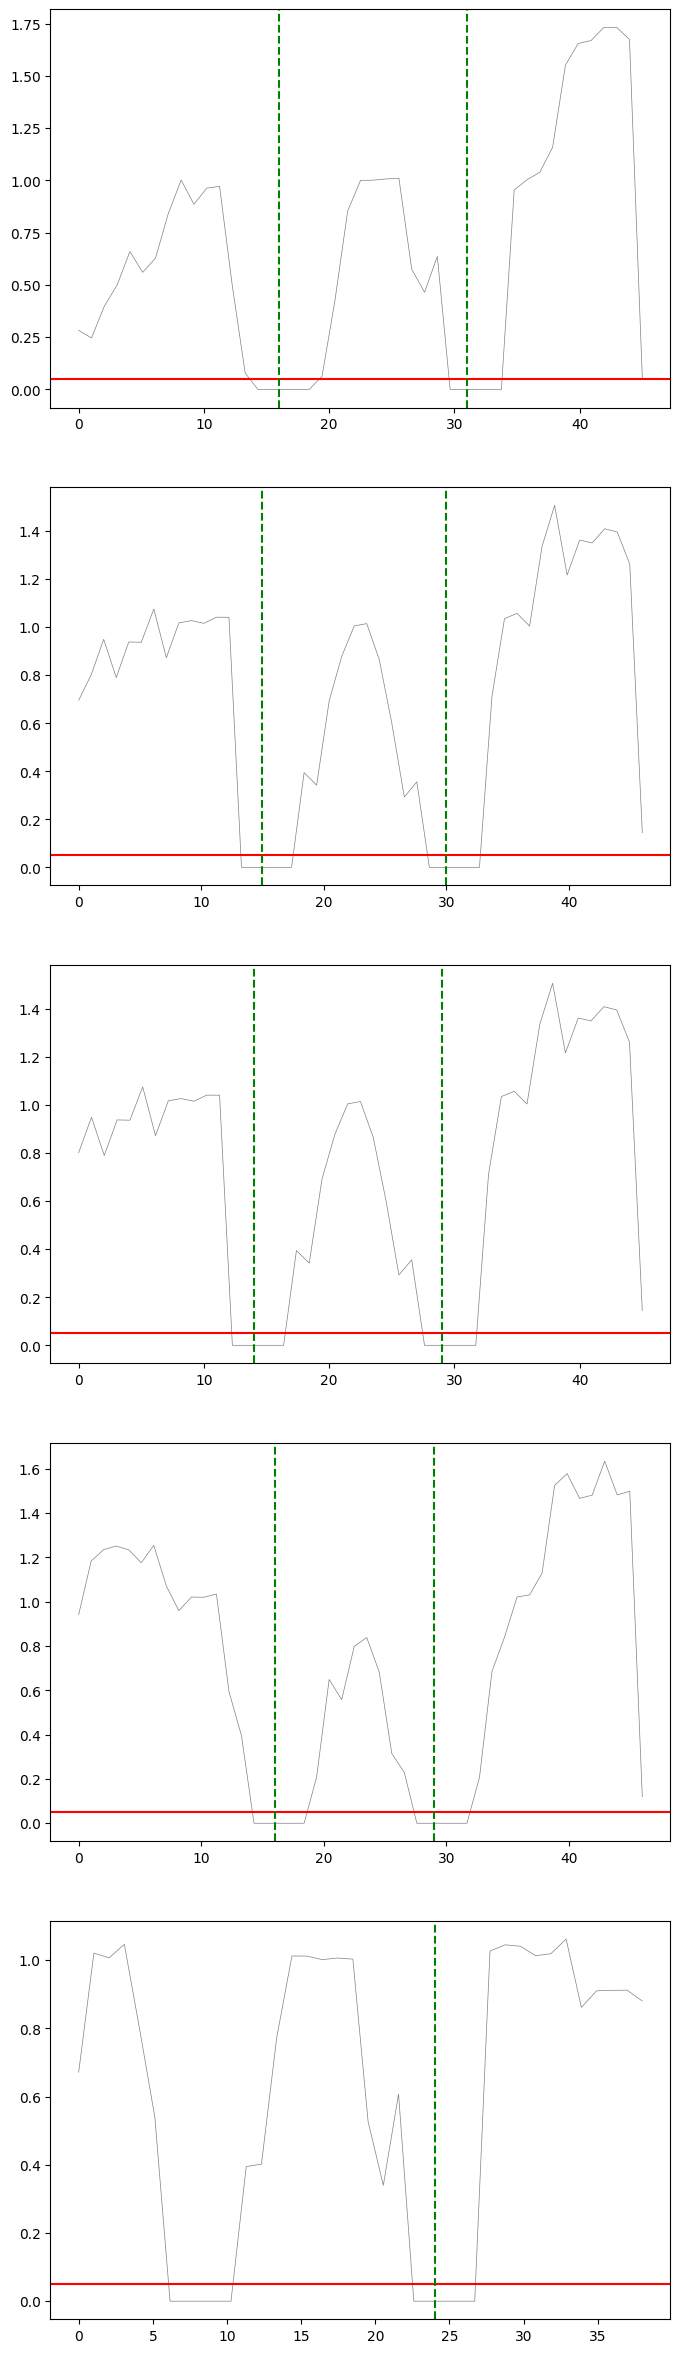

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

...

Time-based init:   0%|          | 0/12 [00:00<?, ?it/s]

Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/7 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/12 [00:00<?, ?it/s]

((array([[3.47e+013, 5.38e+013, 4.40e+013, 1.45e+012, 6.75e+011, 7.14e+010,
          1.55e+009, 8.14e+006, 4.61e+003, 2.11e+001, 5.19e-003, 2.08e-008,
          4.75e-019, 1.06e-039, 6.22e-066, 2.27e-121, 4.29e-126, 2.60e+013,
          8.82e+013, 6.06e+013, 1.29e+013, 4.69e+011, 4.99e+010, 3.54e+008,
          2.46e+005, 6.63e+001, 1.36e-002, 1.04e-006, 3.89e-012, 4.83e-015,
          2.78e-021, 5.28e-050, 2.80e-115, 1.09e-119, 6.38e+013, 1.20e+014,
          6.64e+013, 2.37e+013, 1.30e+012, 2.50e+010, 5.49e+007, 3.99e+004,
          6.47e+002, 1.75e-001, 1.62e-005, 6.94e-011, 8.75e-017, 6.64e-045,
          1.38e-048, 9.32e-114, 3.14e-118, 4.76e+012, 1.98e+013, 3.94e+012,
          1.23e+010, 6.60e+005, 1.23e+000, 7.66e-003, 4.16e-006, 1.90e-008,
          1.85e-010, 8.82e-015, 5.21e-021, 9.12e-032, 9.48e-062, 5.03e-116,
          2.31e-183, 2.52e-188, 3.73e+013, 5.81e+013, 4.97e+012, 4.08e+006,
          1.00e-056, 7.96e-058, 3.03e-059, 5.54e-061, 5.33e-126, 1.52e-196,
          1.

In [4]:
agent.model.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,))


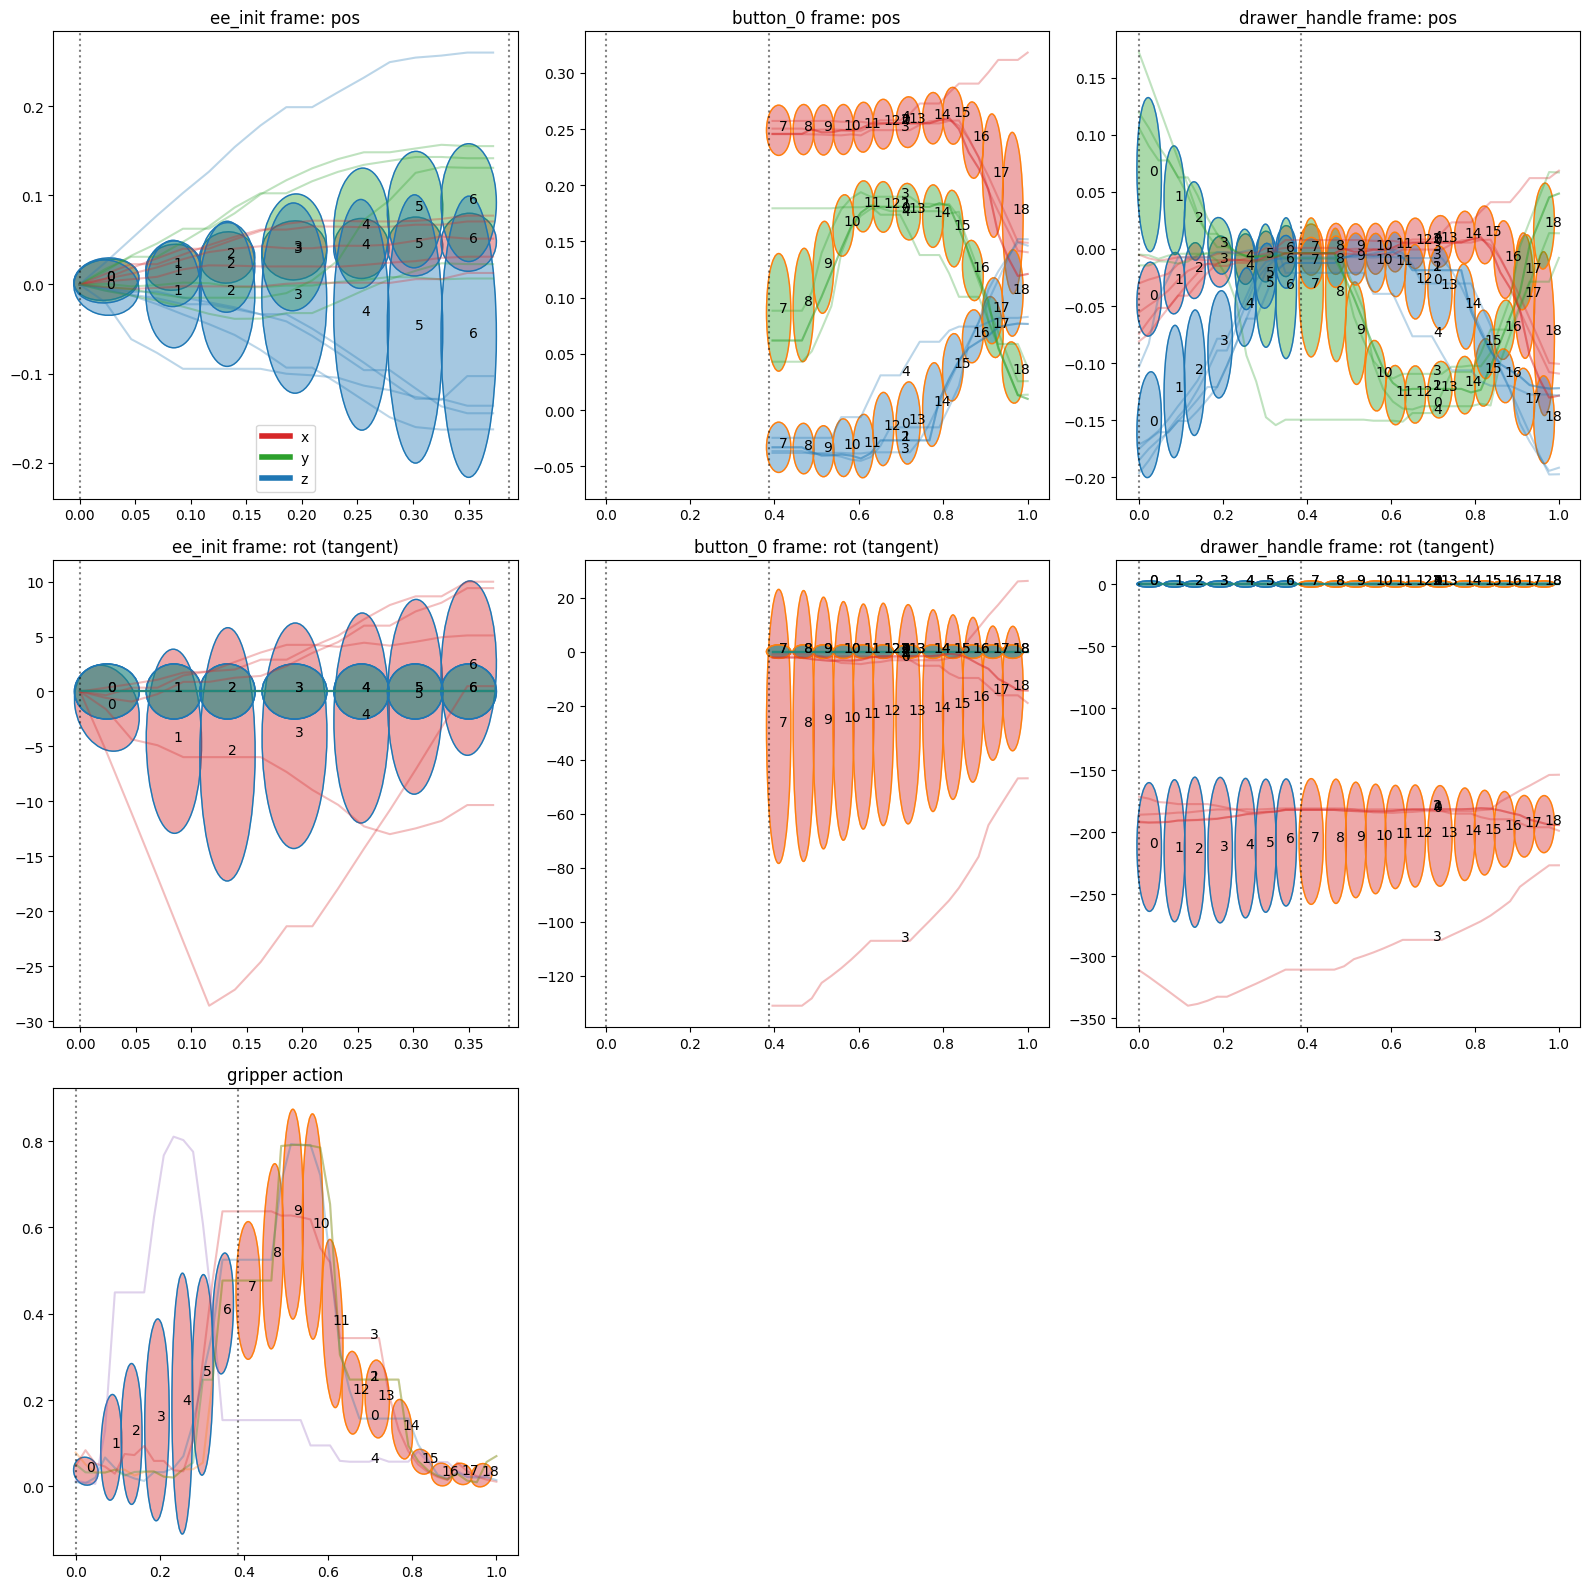

In [5]:
agent.model.plot_model(scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False)


In [6]:
agent.model.fit_trajectories(demos, fix_frames=True, fitting_actions=(FittingStage.EM_HMM, ))


Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[1.00e+000, 1.00e+000, 9.72e-001, 3.50e-001, 3.50e-003, 7.37e-008,
          2.03e-017, 3.10e-032, 9.81e-055, 7.54e-086, 4.32e-127, 1.38e-177,
          3.40e-227, 4.91e-280, 0.00e+000, 0.00e+000, 0.00e+000, 1.00e+000,
          1.00e+000, 9.82e-001, 3.09e-001, 1.65e-003, 1.07e-007, 2.25e-017,
          5.00e-033, 3.49e-055, 4.45e-084, 1.01e-121, 1.88e-168, 6.13e-216,
          1.97e-264, 2.87e-309, 0.00e+000, 0.00e+000, 1.00e+000, 1.00e+000,
          9.67e-001, 5.95e-001, 7.13e-003, 5.46e-009, 1.72e-018, 1.22e-032,
          4.38e-053, 4.81e-082, 1.65e-120, 4.10e-167, 8.07e-215, 1.26e-263,
          6.36e-308, 0.00e+000, 0.00e+000, 1.00e+000, 1.00e+000, 9.97e-001,
          8.85e-005, 3.77e-018, 1.45e-041, 1.69e-072, 4.59e-108, 2.79e-154,
          7.48e-219, 5.23e-303, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 1.00e+000, 8.35e-001, 1.54e-006, 1.35e-018,
          1.68e-036, 3.20e-056, 5.69e-080, 5.22e-115, 1.62e-164, 1.26e-228,
          3.

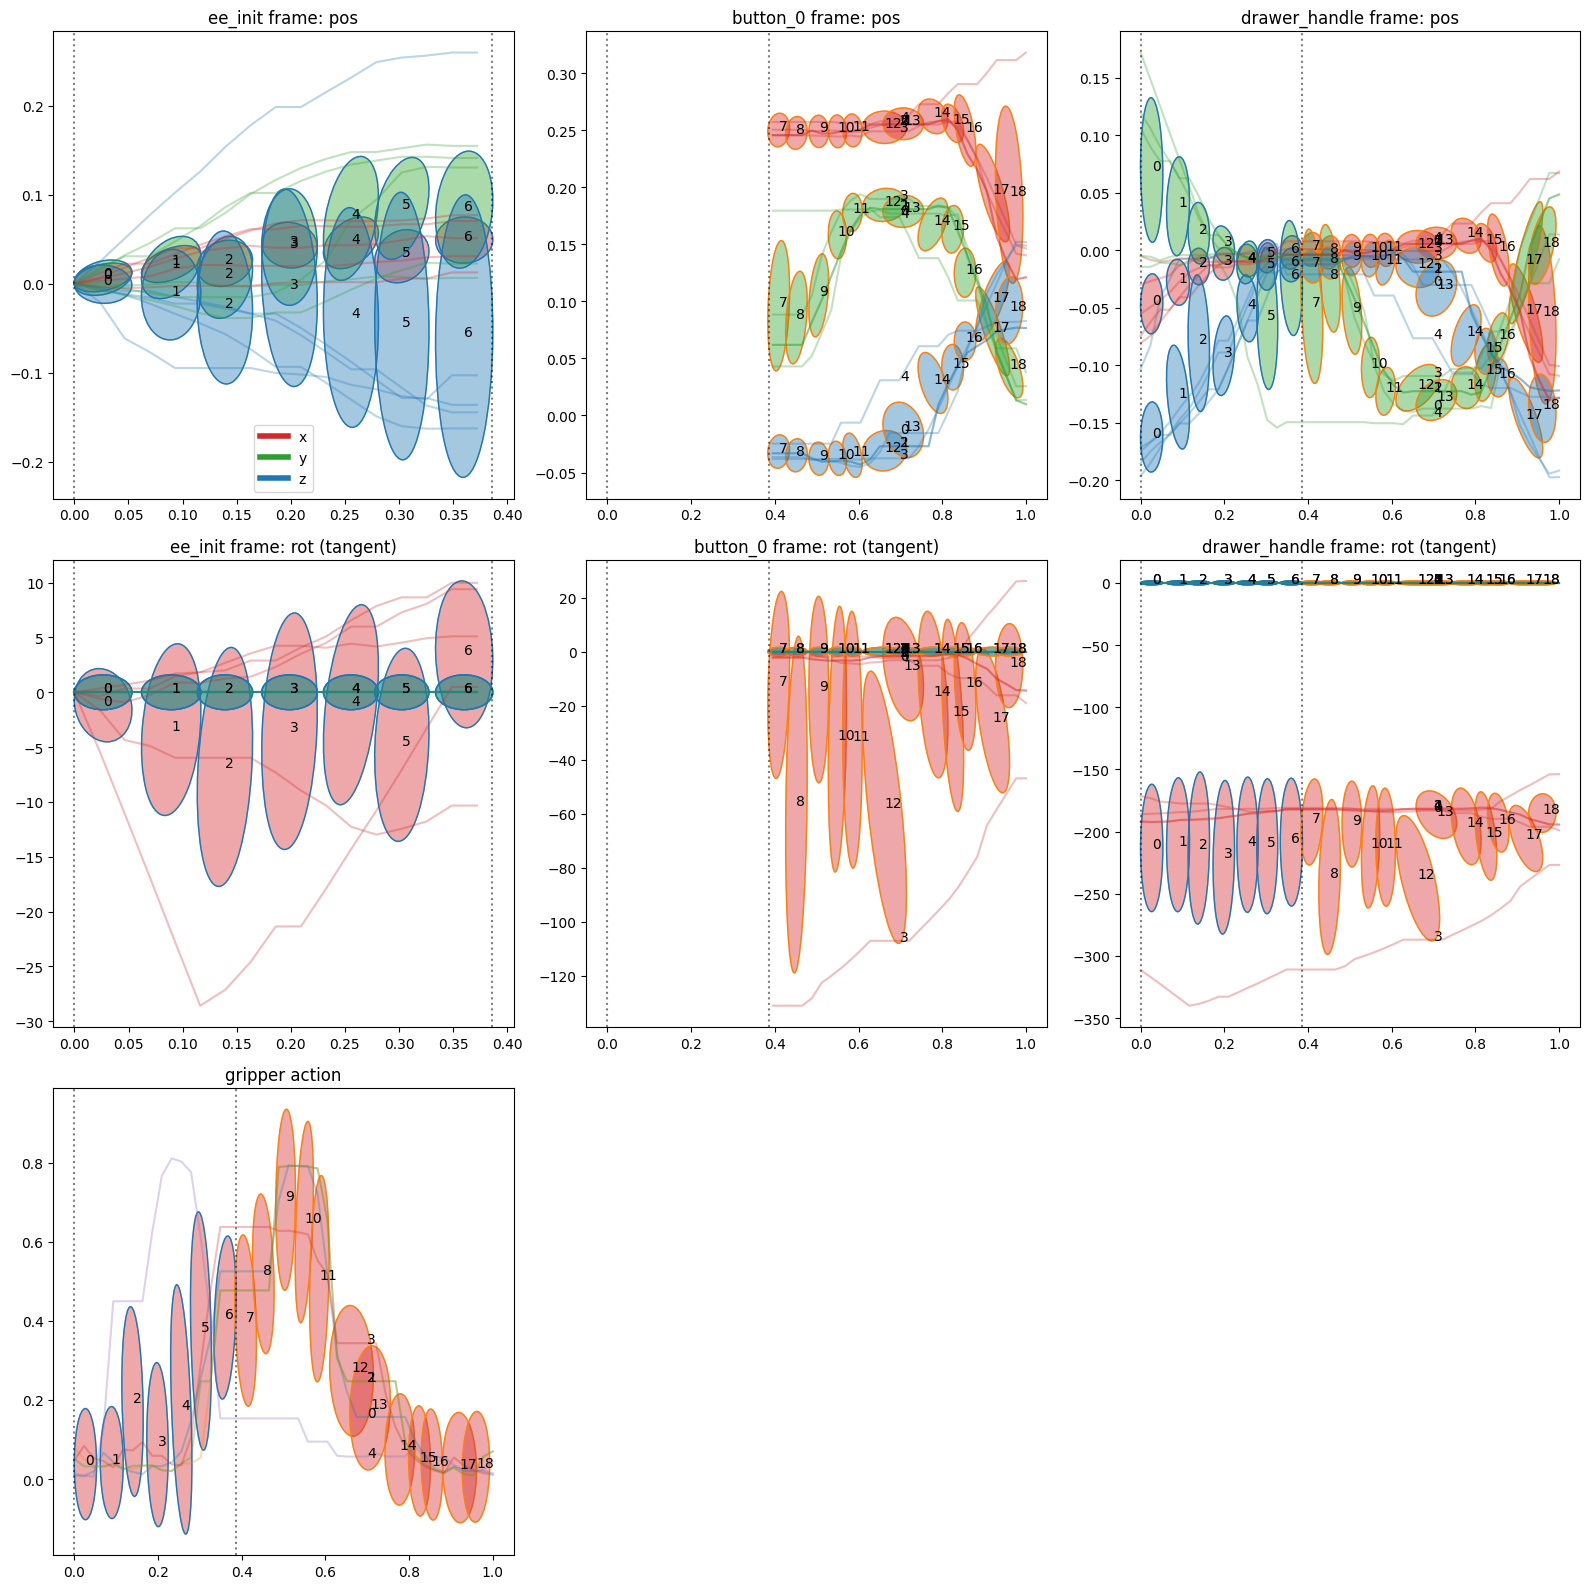

In [7]:
agent.model.plot_model(
    scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False, time_based=True,
)

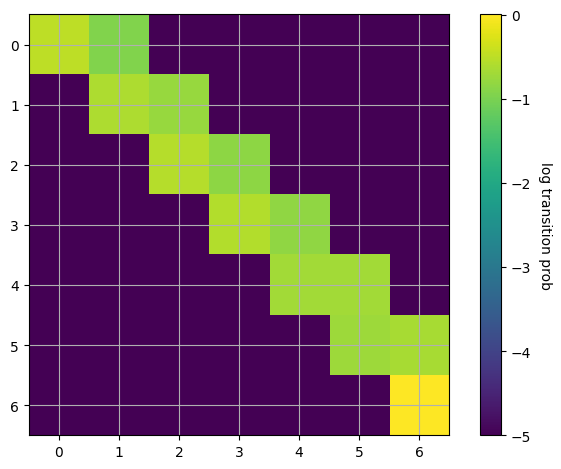

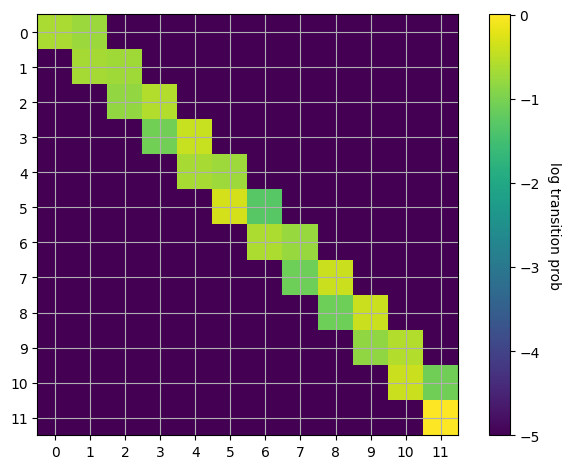

In [8]:
agent.model.plot_hmm_transition_matrix()

In [9]:
TapasAgent.save(agent_cfg)

AttributeError: 'Config' object has no attribute 'save_dir'

In [ ]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = agent.model.reconstruct(
    strategy=ReconstructionStrategy.GMR,
    use_ss=False)


In [ ]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

In [ ]:
agent.model.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [ ]:
agent.model.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=False,
    equal_aspect=True,
    per_segment=False,
)